# **Detección de Adenocarcinoma y Carcinoma Escamoso en imágenes histopatológicas mediante Aprendizaje Profundo.**

<img src="https://img.lb.wbmdstatic.com/vim/live/webmd/consumer_assets/site_images/article_thumbnails/BigBead/adenocarcinoma_bigbead/1800x1200_stomach_adenocarcinoma_bigbead.jpg?resize=750px:*&output-quality=75" alt="Título de la Imagen" width="30%">

<small>Tomada de: webmd.com</small>

## **Introducción**


El análisis de imágenes médicas se ha convertido en un componente fundamental dentro del diagnóstico clínico moderno. En particular, la histología, que estudia los tejidos biológicos a nivel microscópico, permite identificar alteraciones celulares asociadas a diversas enfermedades, entre ellas distintos tipos de cáncer.

Tradicionalmente, el diagnóstico histopatológico depende del análisis visual realizado por especialistas, lo cual requiere una alta experiencia y tiempo considerable, además de que puede estar sujeto a variaciones interpretativas.

Con el avance de la Inteligencia Artificial y el aprendizaje profundo (Deep Learning), se han desarrollado herramientas capaces de analizar grandes volúmenes de imágenes médicas y detectar patrones complejos con alta precisión.

En este proyecto se propone el desarrollo de un modelo de inteligencia artificial para la clasificación automática de imágenes histológicas en tres categorías:

Adenocarcinoma

Tejido benigno

Carcinoma de células escamosas

El dataset utilizado contiene 15,000 imágenes, distribuidas equitativamente entre las tres clases, y organizadas en conjuntos de entrenamiento, validación y prueba. El objetivo es entrenar un modelo capaz de identificar patrones morfológicos característicos de cada tipo de tejido.



## **¿Qué es la Histología?**

La histología es una rama de la biología y la medicina que se encarga del estudio microscópico de los tejidos biológicos. Su propósito es analizar la estructura, organización y características de las células que conforman los tejidos de los organismos vivos.

Para estudiar estos tejidos se utilizan microscopios y diferentes técnicas de preparación de muestras, como fijación, corte y tinción. Estas técnicas permiten observar las estructuras celulares con mayor claridad y detectar posibles anomalías.

En el ámbito médico, la histología es fundamental para el diagnóstico de enfermedades, especialmente en el estudio del cáncer. Los especialistas analizan muestras de tejido obtenidas mediante biopsias para identificar cambios en la forma, tamaño y organización de las células.

En este proyecto se analizan tres tipos de tejidos presentes en el dataset:

Adenocarcinoma: cáncer que se origina en células glandulares.

Carcinoma de células escamosas: cáncer que se desarrolla en células planas que recubren tejidos.

Tejido benigno: tejido normal que no presenta características cancerígenas.


## **Justificación**

El cáncer es una de las principales causas de mortalidad a nivel mundial, por lo que su detección temprana es fundamental para mejorar las probabilidades de tratamiento y supervivencia de los pacientes.

El análisis de imágenes histológicas es una etapa crítica en el diagnóstico médico, ya que permite identificar alteraciones en la estructura de los tejidos. Sin embargo, este proceso suele ser complejo y requiere una gran experiencia por parte de los especialistas.

La implementación de modelos de inteligencia artificial para la clasificación de imágenes médicas permite automatizar parte del proceso de análisis, reduciendo tiempos de diagnóstico y proporcionando herramientas de apoyo para los profesionales de la salud.

Además, este proyecto permite aplicar técnicas de visión por computador y aprendizaje profundo, integrando conocimientos de ciencia de datos con aplicaciones reales en el campo de la medicina.




## Importamos Librerías Necesarias

In [ ]:
# @title
import kagglehub
import os
import os
import shutil
import random
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import seaborn as sns



## Descarga del DataSet

In [ ]:
path = kagglehub.dataset_download("rm1000/lung-cancer-histopathological-images")

dataset_path = path
classes = sorted(os.listdir(dataset_path))
print(f"Clases detectadas: {classes}")
print(f"Número de clases: {len(classes)}")

Using Colab cache for faster access to the 'lung-cancer-histopathological-images' dataset.
Clases detectadas: ['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']
Número de clases: 3


## Nueva Distribución del DataSet

In [ ]:
## Preprocesamiento del Dataset: División, Distribución y Normalización

# Función auxiliar para contar imágenes en un directorio
def count_images_in_directory(directory_path):
    image_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')
    return len([f for f in os.listdir(directory_path) if f.lower().endswith(image_extensions)])

# --- 1. Configuración de Rutas y Proporciones ---
splits_base_dir = "dataset_splits"
split_names = ["train", "validation", "test"]

train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15
image_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')

# --- 2. Función para Crear y Distribuir los Splits del Dataset ---
def create_and_distribute_splits(dataset_path, classes, splits_base_dir, train_ratio, val_ratio, test_ratio, image_extensions):
    # Eliminar el directorio si ya existe para asegurar un comienzo limpio
    if os.path.exists(splits_base_dir):
        shutil.rmtree(splits_base_dir)
        print(f"Directorio '{splits_base_dir}' existente eliminado.")

    # Crear estructura de carpetas para los splits
    for split in split_names:
        for c in classes:
            os.makedirs(os.path.join(splits_base_dir, split, c), exist_ok=True)
    print("Estructura de directorios de splits creada.")

    # Rutas base para los splits
    train_path = os.path.join(splits_base_dir, "train")
    val_path = os.path.join(splits_base_dir, "validation")
    test_path = os.path.join(splits_base_dir, "test")

    # Distribuir imágenes en los splits
    for c in classes:
        original_path = os.path.join(dataset_path, c)
        images = [f for f in os.listdir(original_path) if f.lower().endswith(image_extensions)]
        random.shuffle(images) # Permutación

        total = len(images)
        train_n = int(total * train_ratio)
        val_n = int(total * val_ratio)

        train_imgs = images[:train_n]
        val_imgs = images[train_n:train_n + val_n]
        test_imgs = images[train_n + val_n:]

        # Copiar imágenes
        for img in train_imgs:
            shutil.copy2(os.path.join(original_path, img), os.path.join(train_path, c))
        for img in val_imgs:
            shutil.copy2(os.path.join(original_path, img), os.path.join(val_path, c))
        for img in test_imgs:
            shutil.copy2(os.path.join(original_path, img), os.path.join(test_path, c))
    print("Distribución del dataset completa.")
    return train_path, val_path, test_path

# Ejecutar la distribución de los splits
train_path, val_path, test_path = create_and_distribute_splits(
    dataset_path, classes, splits_base_dir, train_ratio, val_ratio, test_ratio, image_extensions
)

# --- 3. Resumen de la Distribución del Dataset ---
print("\n### Resumen de la distribución de imágenes por clase y split:")
summary = []
for c in classes:
    train_count = count_images_in_directory(os.path.join(train_path, c))
    val_count = count_images_in_directory(os.path.join(val_path, c))
    test_count = count_images_in_directory(os.path.join(test_path, c))
    summary.append([c, train_count, val_count, test_count, train_count + val_count + test_count])

df_summary = pd.DataFrame(summary, columns=["Clase","Train","Validation","Test","Total"])
print("-" * 60)
print(df_summary)
print("-" * 60)

# --- 4. Normalización de Imágenes y Creación de Generadores de Datos ---
print("\n### Normalización de Imágenes y Carga de Datos con ImageDataGenerator")
print("Preparando generadores de datos con normalización...")

IMAGE_SIZE = (768, 768)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True)

validation_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False)

print("Generadores de datos creados exitosamente.")
print(f"Clases encontradas por el generador de entrenamiento: {train_generator.class_indices}")


Directorio 'dataset_splits' existente eliminado.
Estructura de directorios de splits creada.
Distribución del dataset completa.

### Resumen de la distribución de imágenes por clase y split:
------------------------------------------------------------
                     Clase  Train  Validation  Test  Total
0           adenocarcinoma   3500         750   750   5000
1                   benign   3500         750   750   5000
2  squamous_cell_carcinoma   3500         750   750   5000
------------------------------------------------------------

### Normalización de Imágenes y Carga de Datos con ImageDataGenerator
Preparando generadores de datos con normalización...
Found 10500 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.
Generadores de datos creados exitosamente.
Clases encontradas por el generador de entrenamiento: {'adenocarcinoma': 0, 'benign': 1, 'squamous_cell_carcinoma': 2}


Este código **divide** el *dataset* de imágenes histopatológicas en conjuntos de **entrenamiento, validación y prueba**, asegurando que cada uno tenga una distribución balanceada de las tres clases (Adenocarcinoma, Benigno, Carcinoma Escamoso).

También **normaliza** los valores de píxeles de las imágenes (de 0-255 a 0-1) y crea **generadores de datos** que cargarán las imágenes por lotes, listos para alimentar un modelo de *Deep Learning*.

### Aporte al Proyecto:

Este paso es **crítico** porque organiza y prepara los datos de manera óptima, lo que es esencial para un entrenamiento **eficiente y robusto** del modelo de clasificación, asegurando que aprenda de un conjunto de datos bien estructurado y escalado.

## Verificación de las **rutas**

In [ ]:
print("\n--- Verificación Final de Rutas del Dataset (Después del Split) ---")
print(f"Dataset Original Path: {dataset_path}")
print(f"Existe: {os.path.exists(dataset_path)}\n")

print(f"Train Path (Split): {train_path}")
print(f"Existe: {os.path.exists(train_path)}\n")

print(f"Validation Path (Split): {val_path}")
print(f"Existe: {os.path.exists(val_path)}\n")

print(f"Test Path (Split): {test_path}")
print(f"Existe: {os.path.exists(test_path)}")
print("------------------------------------------------------------------\n")

if os.path.exists(train_path):
    # Re-verify classes based on the new train split directory
    new_classes = sorted(os.listdir(train_path))
    print(f"Clases detectadas en el split de entrenamiento: {new_classes}")
    print(f"Número de clases: {len(new_classes)}")
else:
    print(f"No se pudo obtener las clases, el directorio de entrenamiento no existe: {train_path}")



--- Verificación Final de Rutas del Dataset (Después del Split) ---
Dataset Original Path: /kaggle/input/lung-cancer-histopathological-images
Existe: True

Train Path (Split): dataset_splits/train
Existe: True

Validation Path (Split): dataset_splits/validation
Existe: True

Test Path (Split): dataset_splits/test
Existe: True
------------------------------------------------------------------

Clases detectadas en el split de entrenamiento: ['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']
Número de clases: 3


## Imágenes de muestra



Displaying 3 sample images for each of the 3 classes from the training split...


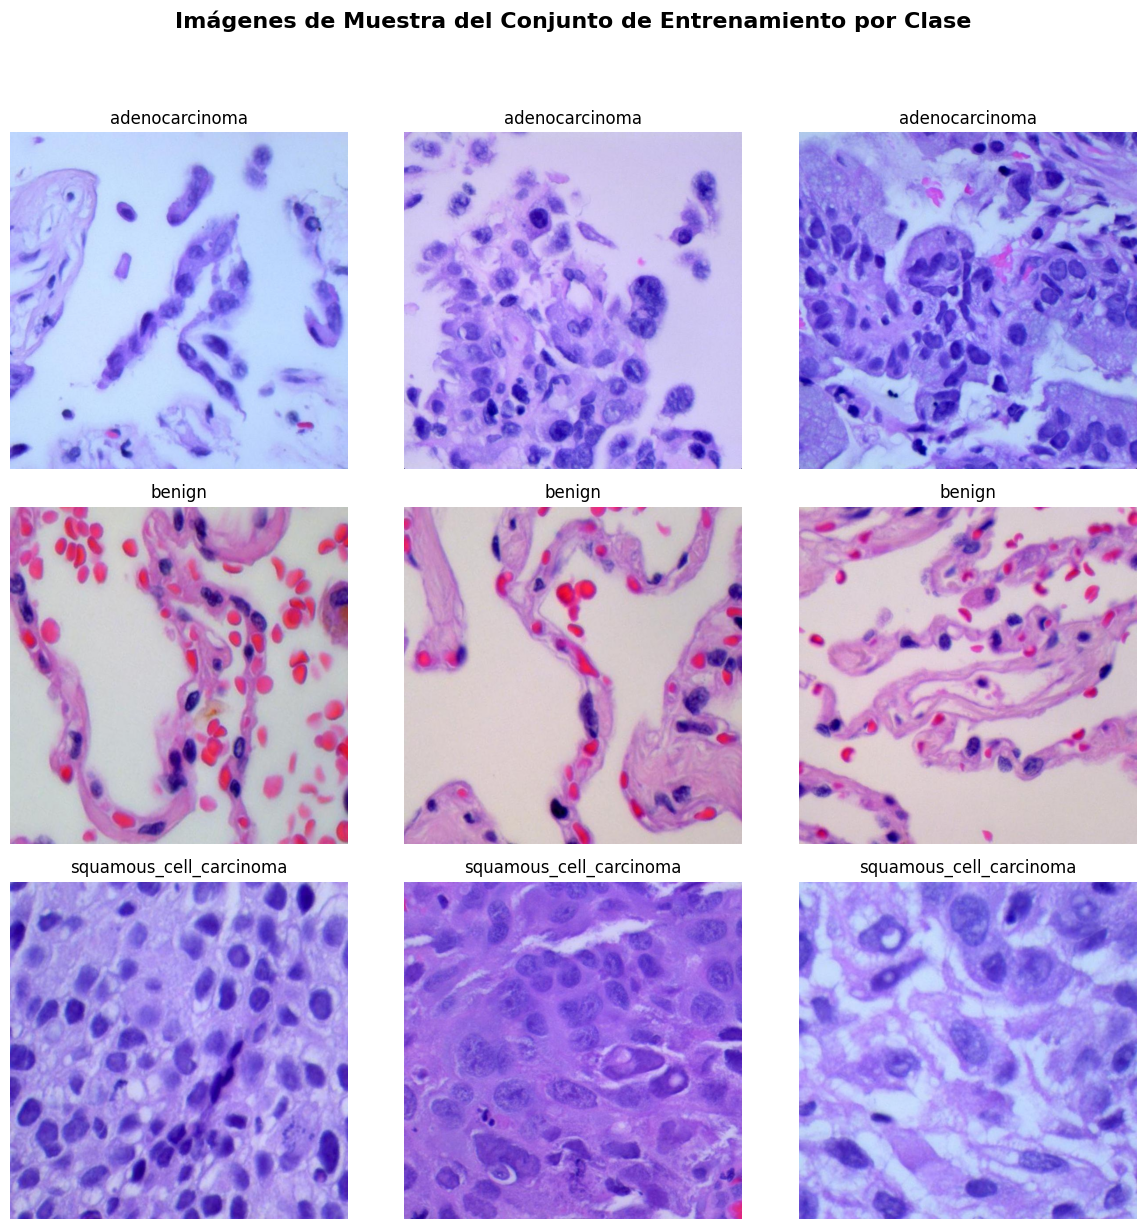

Sample images displayed.


In [ ]:
# 1. Define the number of sample images to display for each class
num_sample_images_per_class = 3

# Calculate total number of images for subplot grid
total_classes = len(classes)

# Determine grid size (e.g., rows x num_sample_images_per_class)
rows = total_classes # One row per class
cols = num_sample_images_per_class

plt.figure(figsize=(cols * 4, rows * 4))

# Add a general title for the entire figure
plt.suptitle('Imágenes de Muestra del Conjunto de Entrenamiento por Clase', fontsize=16, fontweight='bold', y=1.02) # Adjust y for spacing

print(f"Displaying {num_sample_images_per_class} sample images for each of the {total_classes} classes from the training split...")

image_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')

i = 0 # Counter for subplot index
# 2. Iterate through each class
for class_name in classes:
    # 3. Construct the full path to its directory within the training split
    class_dir_path = os.path.join(train_path, class_name)

    # 4. Get a list of all image file paths within that class directory
    all_images_in_class = [os.path.join(class_dir_path, f)
                           for f in os.listdir(class_dir_path)
                           if f.lower().endswith(image_extensions)]

    # Ensure there are enough images to sample
    if len(all_images_in_class) < num_sample_images_per_class:
        print(f"Warning: Not enough images in class '{class_name}' ({len(all_images_in_class)} found) to display {num_sample_images_per_class} samples. Displaying all available.")
        sample_image_paths = all_images_in_class
    else:
        # 5. Randomly select the predefined number of sample image paths
        sample_image_paths = random.sample(all_images_in_class, num_sample_images_per_class)

    # 6. For each selected image path:
    for img_path in sample_image_paths:
        i += 1
        plt.subplot(rows, cols, i)

        # a. Load the image
        img = load_img(img_path)
        # b. Convert the image to a NumPy array (optional for display, but good practice)
        img_array = img_to_array(img)

        # c. Display the image
        plt.imshow(img_array.astype('uint8')) # Convert to uint8 for proper display
        # d. Set the subplot title to indicate the class name (increased fontsize)
        plt.title(class_name, fontsize=12) # Increased font size here
        # e. Turn off the axis ticks for better visualization
        plt.axis('off')

# 7. Adjust the layout and display the figure
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle from overlapping
plt.show()
print("Sample images displayed.")

## Visualización

--- Resumen y Análisis Estadístico del Dataset ---
Analizando propiedades de 50 imágenes aleatorias por clase...

## 1. Distribución de Clases General
El dataset cuenta con una distribución perfectamente balanceada:


,Clase,Total
0,adenocarcinoma,5000
1,benign,5000
2,squamous_cell_carcinoma,5000



## 2. Distribución de Clases por Split (Entrenamiento, Validación, Prueba)
La división del dataset mantiene el balance de clases en cada split:


,Clase,Train,Validation,Test
0,adenocarcinoma,3500,750,750
1,benign,3500,750,750
2,squamous_cell_carcinoma,3500,750,750


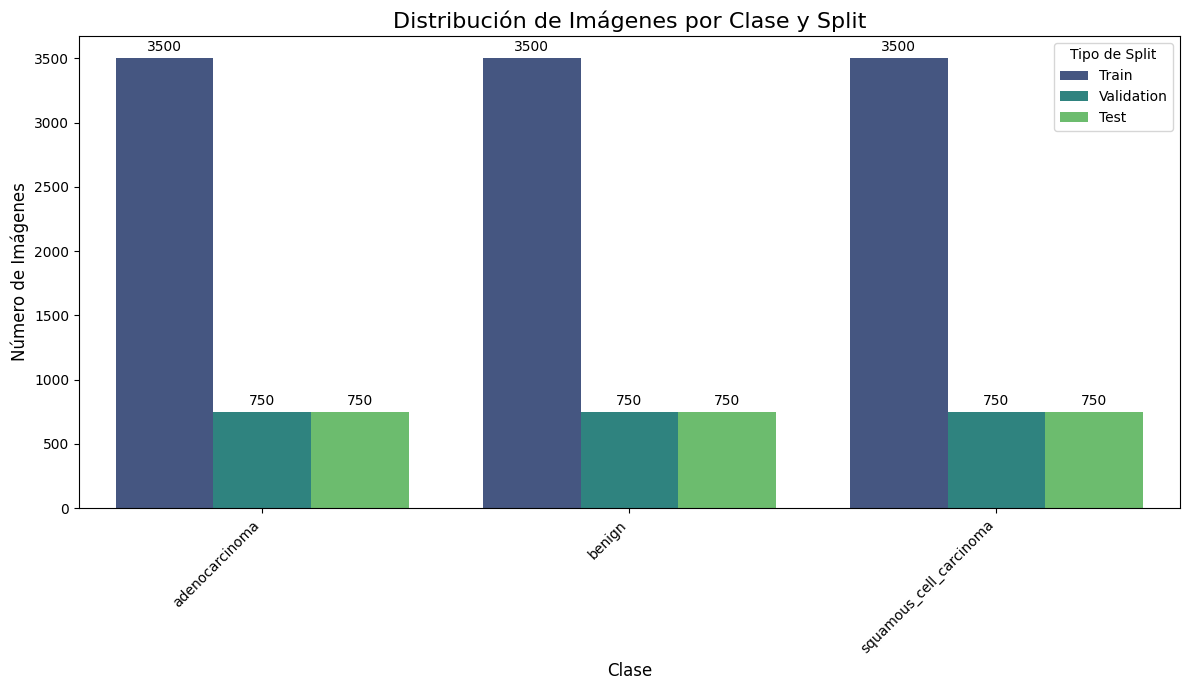


## 3. Propiedades de las Imágenes (Dimensiones y Canales)
Las imágenes del dataset son uniformes en tamaño y profundidad de color:


,width,height,channels
count,150.0,150.0,150.0
mean,768.0,768.0,3.0
std,0.0,0.0,0.0
min,768.0,768.0,3.0
25%,768.0,768.0,3.0
50%,768.0,768.0,3.0
75%,768.0,768.0,3.0
max,768.0,768.0,3.0



- Dimensiones únicas de las imágenes: [[768, 768]]
- Número de canales únicos: [3]

--- Conclusión General del Análisis Estadístico ---
El dataset es ideal para el entrenamiento de modelos de clasificación debido a su perfecto balance de clases y la uniformidad en las propiedades de las imágenes (tamaño 768x768 píxeles, 3 canales RGB). La estrategia de división de datos empleada también asegura que cada split mantenga esta distribución balanceada, lo cual es crucial para evitar sesgos durante el entrenamiento y evaluación del modelo.


In [ ]:

print("--- Resumen y Análisis Estadístico del Dataset ---")

# --- Código para definir df_image_properties (movido aquí para asegurar su definición) ---
image_properties = []
num_images_to_sample = 50 # Número de imágenes a muestrear por clase para el análisis de propiedades

print(f"Analizando propiedades de {num_images_to_sample} imágenes aleatorias por clase...")

# Asegurar que image_extensions esté definido localmente
image_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')

for class_name in classes:
    class_dir_path = os.path.join(dataset_path, class_name)
    all_images_in_class = [os.path.join(class_dir_path, f)
                           for f in os.listdir(class_dir_path)
                           if f.lower().endswith(image_extensions)]

    # Muestrear un subconjunto de imágenes para el análisis
    sample_paths = random.sample(all_images_in_class, min(len(all_images_in_class), num_images_to_sample))

    for img_path in sample_paths:
        try:
            img = load_img(img_path)
            img_array = img_to_array(img)
            height, width, channels = img_array.shape
            image_properties.append({
                'class': class_name,
                'width': width,
                'height': height,
                'channels': channels
            })
        except Exception as e:
            print(f"No se pudo procesar la imagen {img_path}: {e}")

# Crear un DataFrame con las propiedades recopiladas
df_image_properties = pd.DataFrame(image_properties)
# --- Fin del código para definir df_image_properties ---

print("\n## 1. Distribución de Clases General")
print("El dataset cuenta con una distribución perfectamente balanceada:")
display(df_summary[['Clase', 'Total']])


print("\n## 2. Distribución de Clases por Split (Entrenamiento, Validación, Prueba)")
print("La división del dataset mantiene el balance de clases en cada split:")
display(df_summary[['Clase', 'Train', 'Validation', 'Test']])

# Preparar los datos para la visualización (derretir el DataFrame)
df_melted = df_summary.melt(id_vars=['Clase'], var_name='Tipo de Split', value_name='Número de Imágenes')
# Excluir la columna 'Total' del melted DataFrame para el gráfico de splits
df_melted = df_melted[df_melted['Tipo de Split'] != 'Total']

# Se incluye el gráfico de barras agrupadas para una visión consolidada del análisis estadístico
plt.figure(figsize=(12, 7))
sns.barplot(x='Clase', y='Número de Imágenes', hue='Tipo de Split', data=df_melted, palette='viridis')
plt.title('Distribución de Imágenes por Clase y Split', fontsize=16)
plt.xlabel('Clase', fontsize=12)
plt.ylabel('Número de Imágenes', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo de Split')

# Añadir etiquetas de valor en las barras para hacer las subdivisiones más explícitas
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.tight_layout()
plt.show()


print("\n## 3. Propiedades de las Imágenes (Dimensiones y Canales)")
print("Las imágenes del dataset son uniformes en tamaño y profundidad de color:")
display(df_image_properties[['width', 'height', 'channels']].describe())

print(f"\n- Dimensiones únicas de las imágenes: {df_image_properties[['width', 'height']].drop_duplicates().values.tolist()}")
print(f"- Número de canales únicos: {df_image_properties['channels'].unique().tolist()}")


print("\n--- Conclusión General del Análisis Estadístico ---")
print("El dataset es ideal para el entrenamiento de modelos de clasificación debido a su perfecto balance de clases y la uniformidad en las propiedades de las imágenes (tamaño 768x768 píxeles, 3 canales RGB). La estrategia de división de datos empleada también asegura que cada split mantenga esta distribución balanceada, lo cual es crucial para evitar sesgos durante el entrenamiento y evaluación del modelo.")


## Distribución del Ancho de las Imágenes

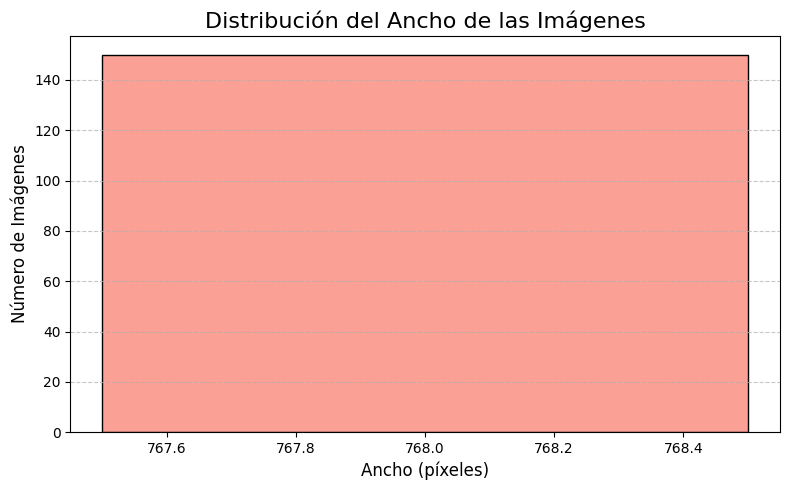

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df_image_properties['width'], bins=1, kde=False, color='salmon')
plt.title('Distribución del Ancho de las Imágenes', fontsize=16)
plt.xlabel('Ancho (píxeles)', fontsize=12)
plt.ylabel('Número de Imágenes', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Análisis RGB de una imagen**

Analizando imagen: dataset_splits/train/benign/4260.jpg


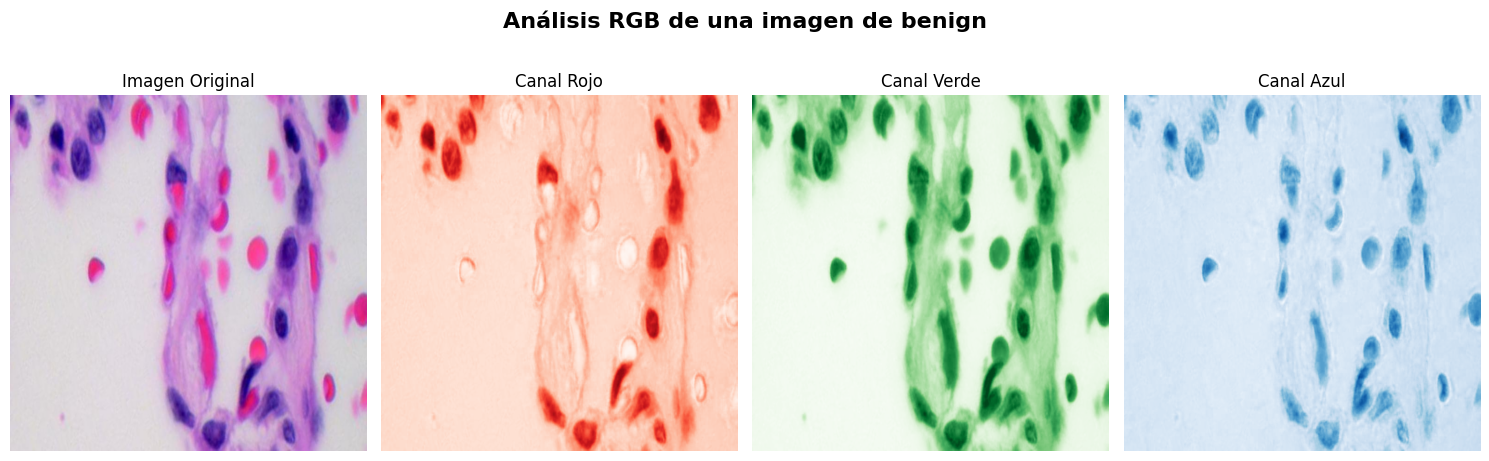

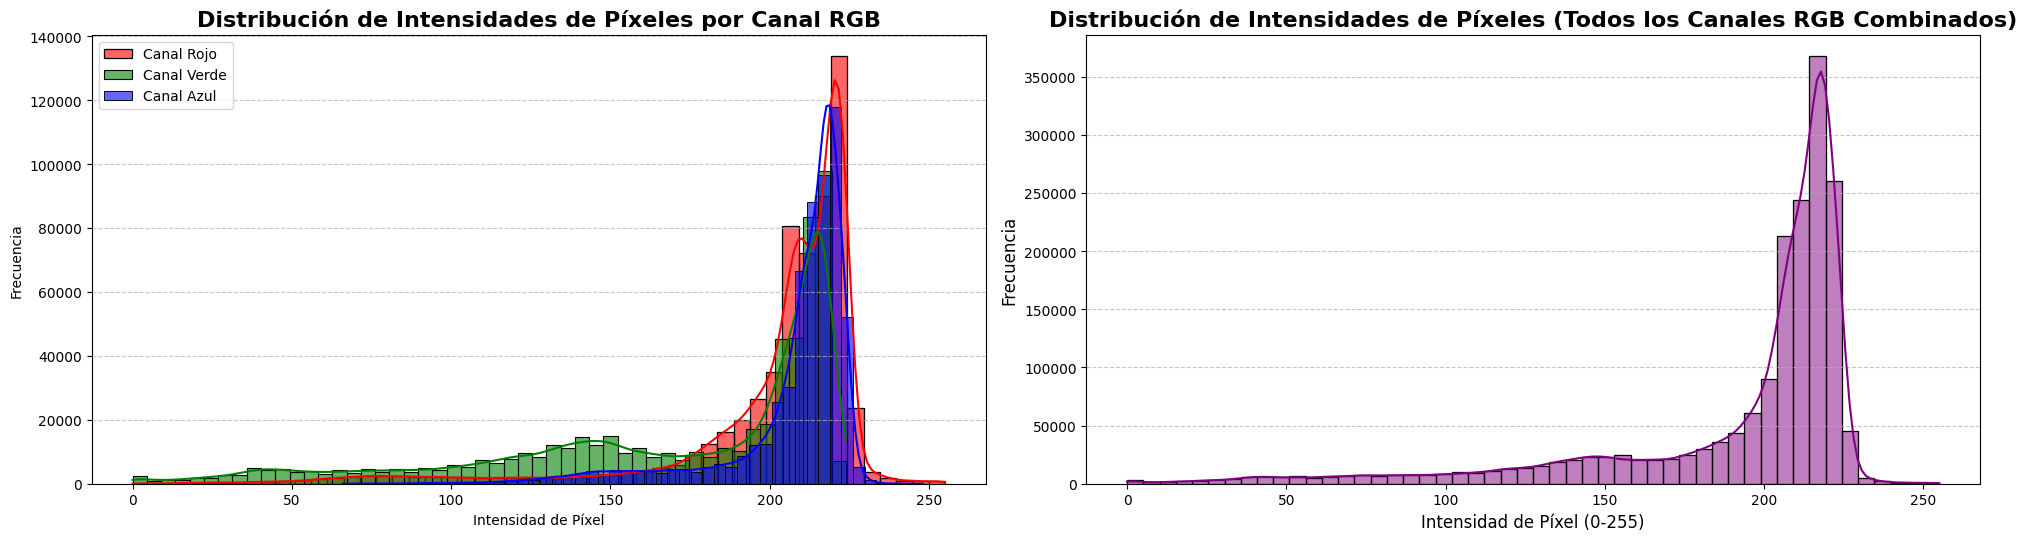

In [ ]:
# @title
# Obtener una clase aleatoria
random_class = random.choice(classes)

# Construir la ruta al directorio de la clase aleatoria en el split de entrenamiento
class_dir_path = os.path.join(train_path, random_class)

# Obtener todas las imágenes en esa clase
all_images_in_class = [os.path.join(class_dir_path, f)
                       for f in os.listdir(class_dir_path)
                       if f.lower().endswith(image_extensions)]

# Seleccionar una imagen aleatoria de la lista
if not all_images_in_class:
    print(f"No se encontraron imágenes en la clase: {random_class}")
else:
    random_image_path = random.choice(all_images_in_class)
    print(f"Analizando imagen: {random_image_path}")

    # Cargar la imagen
    img = load_img(random_image_path)
    img_array = img_to_array(img)

    # Normalizar los valores de píxeles para visualización en histogramas
    # (generalmente están en el rango 0-255)
    img_array_normalized = img_array / 255.0

    # Separar canales RGB
    r_channel = img_array[:, :, 0]
    g_channel = img_array[:, :, 1]
    b_channel = img_array[:, :, 2]

    # --- Visualización de la Imagen Original y Canales Individuales ---
    plt.figure(figsize=(15, 5))
    plt.suptitle(f'Análisis RGB de una imagen de {random_class}', fontsize=16, fontweight='bold')

    plt.subplot(1, 4, 1)
    plt.imshow(img_array.astype('uint8'))
    plt.title('Imagen Original')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(r_channel, cmap='Reds_r') # Mostrar el canal rojo como un mapa de calor rojo
    plt.title('Canal Rojo')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(g_channel, cmap='Greens_r') # Mostrar el canal verde como un mapa de calor verde
    plt.title('Canal Verde')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(b_channel, cmap='Blues_r') # Mostrar el canal azul como un mapa de calor azul
    plt.title('Canal Azul')
    plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- Histograma de Distribución de Intensidades de Píxeles por Canal RGB (Combinado) ---
    # --- Histograma de Distribución de Intensidades de Píxeles (Todos los Canales RGB Combinados) ---
    # Se combinan ambos histogramas en una sola figura para mostrarlos horizontalmente
    plt.figure(figsize=(20, 6))

    # Primer Subplot: Histograma de canales RGB superpuestos
    plt.subplot(1, 2, 1)
    sns.histplot(r_channel.flatten(), bins=50, color='red', kde=True, label='Canal Rojo', alpha=0.6)
    sns.histplot(g_channel.flatten(), bins=50, color='green', kde=True, label='Canal Verde', alpha=0.6)
    sns.histplot(b_channel.flatten(), bins=50, color='blue', kde=True, label='Canal Azul', alpha=0.6)
    plt.title('Distribución de Intensidades de Píxeles por Canal RGB', fontsize=16, fontweight='bold')
    plt.xlabel('Intensidad de Píxel')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Segundo Subplot: Histograma de todos los canales RGB combinados
    plt.subplot(1, 2, 2)
    all_channels_flattened = img_array.flatten()
    sns.histplot(all_channels_flattened, bins=50, color='purple', kde=True)
    plt.title('Distribución de Intensidades de Píxeles (Todos los Canales RGB Combinados)', fontsize=16, fontweight='bold')
    plt.xlabel('Intensidad de Píxel (0-255)', fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


## Resultado del Análisis RGB de una Imagen

Este código selecciona una imagen aleatoria del dataset y realiza un **análisis de sus componentes de color (RGB)**. Genera:

1.  **Visualización de Canales Individuales**: Muestra la imagen original y cómo se ven sus canales Rojo, Verde y Azul por separado. Esto permite observar qué partes de la imagen son más intensas en cada color.
2.  **Histogramas de Intensidad de Píxeles**: Presenta histogramas que grafican la distribución de las intensidades de los píxeles para cada canal RGB y un histograma combinado de todos los canales. Esto revela la 'huella' de color y brillo de la imagen.

### Aporte al Proyecto:

Este análisis es valioso porque nos ayuda a **entender la composición de color y el contraste de las imágenes histopatológicas**. Nos permite identificar posibles patrones de color específicos de cada clase de cáncer o si existen variaciones significativas en la tinción. Esta información es crucial para decidir si necesitamos aplicar técnicas adicionales de **normalización de color o aumento de datos** (data augmentation) para mejorar la robustez y el rendimiento de nuestro modelo de clasificación.

## Interpretación y Aporte de las Gráficas de Análisis RGB

Dado que cada vez que se ejecuta el código se selecciona una imagen diferente, estas visualizaciones nos ayudan a entender la variabilidad y consistencia de las propiedades de las imágenes dentro de cada clase (Adenocarcinoma, Benigno, Carcinoma de Células Escamosas).

### 1. Imagen Original y Canales RGB Individuales (Mapas de Calor)

*   **Qué Muestra:**
    *   **Imagen Original:** La representación visual directa de la imagen histopatológica seleccionada al azar. Esto nos permite ver la morfología del tejido tal como se presenta en el dataset.
    *   **Canales Rojo, Verde, Azul:** Muestran la intensidad de cada componente de color (rojo, verde, azul) de la imagen original de forma individual. Cada canal se representa como un mapa de calor donde los colores más claros indican mayor intensidad de ese canal y los más oscuros menor intensidad. Por ejemplo, en el canal rojo, las áreas más rojizas/blancas son las que tienen mayor contribución del color rojo.

*   **Interpretación y Aporte al Proyecto:**
    *   **Identificación de Patrones de Color:** Al observar los canales individuales, podemos identificar qué colores predominan en ciertas estructuras celulares o áreas del tejido. Por ejemplo, si un tipo de cáncer tiende a tener más tinción eosinófila (rosada/rojiza), veremos mayor intensidad en el canal rojo en esas zonas.
    *   **Preprocesamiento:** Esta visualización ayuda a entender si es necesario realizar ajustes de color, normalización o aumento de datos (data augmentation) en el futuro. Si una clase muestra consistentemente un sesgo hacia un color específico, podría ser una característica útil para el modelo.
    *   **Consistencia del Dataset:** Al ver diferentes imágenes cada vez, confirmamos que las imágenes tienen una estructura RGB típica y que los canales se distribuyen de manera esperada para imágenes histológicas.

### 2. Distribución de Intensidades de Píxeles por Canal RGB (Combinada)

*   **Qué Muestra:** Un único gráfico que superpone los histogramas de la distribución de intensidad de píxeles para el canal rojo, verde y azul. El eje X representa la intensidad del píxel (de 0 a 255) y el eje Y la frecuencia (cuántos píxeles tienen esa intensidad).

*   **Interpretación y Aporte al Proyecto:**
    *   **Dominancia de Colores:** Nos indica qué rangos de intensidad son más comunes para cada color primario. Por ejemplo, picos en los valores bajos (cerca de 0) sugieren áreas oscuras o con poca presencia de ese color, mientras que picos en valores altos (cerca de 255) sugieren áreas claras o saturadas de ese color.
    *   **Balance de Color:** Permite evaluar el balance general de colores en la imagen. Si un canal tiene una distribución muy diferente a los otros, podría indicar un sesgo de color en la imagen específica o en la clase.
    *   **Variabilidad en la Tinción:** En histología, la tinción (como H&E) introduce variaciones de color. Estos histogramas nos ayudan a cuantificar esa variabilidad y a determinar si hay diferencias significativas entre las distribuciones de color de distintas clases, lo cual podría ser relevante para la clasificación.

### 3. Distribución de Intensidades de Píxeles (Todos los Canales RGB Combinados)

*   **Qué Muestra:** Un histograma que consolida las intensidades de todos los píxeles de los tres canales RGB en una única distribución. Ignora la información de color individual y muestra la distribución general de la 'luminosidad' o 'oscuridad' de los píxeles en la imagen.

*   **Interpretación y Aporte al Proyecto:**
    *   **Contraste General:** Los picos en este histograma revelan los rangos de intensidad más frecuentes en la imagen. Una distribución amplia sugiere buen contraste, mientras que una distribución estrecha podría indicar una imagen de bajo contraste o con dominancia de tonos medios.
    *   **Homogeneidad de Brillo:** Permite evaluar la uniformidad de brillo en la imagen. Si el histograma está sesgado hacia un extremo (todo oscuro o todo claro), podría indicar problemas de iluminación o tinción excesiva/insuficiente en la muestra.
    *   **Normalización:** Esta gráfica es útil para decidir si se necesita una normalización de brillo o contraste para estandarizar las imágenes antes de alimentar un modelo de aprendizaje profundo, lo cual es crucial para mejorar el rendimiento del modelo.

## Refrencias

Borkowski, A. A., Bui, M. M., Thomas, L. B., Wilson, C. P., DeLand, L. A., & Mastorides, S. M. (2019). Lung and Colon Cancer Histopathological Image Dataset (LC25000). En arXiv [eess.IV]. http://arxiv.org/abs/1912.12142

ChatGPT. (s/f). ChatGPT. Recuperado el 10 de marzo de 2026, de https://chatgpt.com/c/69af8da8-73f4-8326-9bb2-c0d3057afd0f

Checking your browser - reCAPTCHA. (s/f). Kaggle.com. Recuperado el 10 de marzo de 2026, de https://www.kaggle.com/datasets/rm1000/lung-cancer-histopathological-images/data?select=benign

projects/sources/2020-1/2142665/Project.ipynb · master · BIVL2AB / Academico / Cursos-UIS / AI / ai-UIS-student ·. (s/f). GitLab. Recuperado el 10 de marzo de 2026, de https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/-/blob/master/projects/sources/2020-1/2142665/Project.ipynb?ref_type=heads

Python 3.14 documentation. (s/f). Python Documentation. Recuperado el 10 de marzo de 2026, de https://docs.python.org/3/

# **----------------------------------**